# EDA 010: Normalization pipeline validation

Run this **after** [`normalize_split_parquets.py`](../../scripts/normalize_split_parquets.py) (see [`configs/normalize_splits.json`](../../configs/normalize_splits.json)).

**Sections 1–5 (checks):** interim vs processed row counts, schema, recompute vs JSON, optional inverse for `votes_helpful`.

**Section 6 (optional EDA):** same themes as [`docs/etl/normalization_notes.md`](../../docs/etl/normalization_notes.md) *Optional EDA checks* — skew/raw vs `_norm`, separation by `recommended` / `is_helpful`, correlations, simple tail stats. Uses a subsample for speed.

**Temporal/hybrid split caveat:** params are still fit on **train** only. If split policy changes to temporal or hybrid cohorts, expect stronger train->val/test drift and more clipping/saturation on transformed tails. Validate by split and by cohort (`<3` vs `>=3` interactions) before comparing model deltas.

Resolves repo root from `notebooks/etl/` so imports work via `sys.path` → `src/`.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

_repo = Path("../..").resolve()
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from steam_review_ml.transforms.normalization import (
    add_normalized_columns,
    inverse_norm_votes_helpful,
    make_norm_col_name,
)

CFG = _repo / "configs" / "normalize_splits.json"
with open(CFG) as f:
    norm_cfg = json.load(f)

params_path = _repo / norm_cfg["params_output_path"]
paths = {
    "train": ("train_input_path", "train_output_path"),
    "val": ("val_input_path", "val_output_path"),
    "test": ("test_input_path", "test_output_path"),
}


def parquet_n_rows(p: Path) -> int:
    return pq.ParquetFile(p).metadata.num_rows


print("repo:", _repo)
print("params:", params_path)


repo: /home/ryanr/workspace/steam_recommendations
params: /home/ryanr/workspace/steam_recommendations/artifacts/normalization_params.json


## 1) Files exist


In [2]:
for split, (inp_k, out_k) in paths.items():
    inp = _repo / norm_cfg[inp_k]
    out = _repo / norm_cfg[out_k]
    assert inp.is_file(), f"missing interim {split}: {inp}"
    assert out.is_file(), f"missing processed {split}: {out} (run normalize script)"
assert params_path.is_file(), f"missing {params_path}"
print("OK: all paths from config exist.")


OK: all paths from config exist.


## 2) Row counts: interim input == processed output (per split)


In [3]:
for split, (inp_k, out_k) in paths.items():
    inp = _repo / norm_cfg[inp_k]
    out = _repo / norm_cfg[out_k]
    ni, no = parquet_n_rows(inp), parquet_n_rows(out)
    assert ni == no, f"{split}: interim rows {ni} != processed {no}"
    print(f"{split}: {ni:,} rows")
print("OK: row counts match.")


train: 5,960,120 rows
val: 1,599,707 rows
test: 1,600,665 rows
OK: row counts match.


## 3) Schema: processed has `_norm_*` for every fitted column; raw columns preserved


In [4]:
with open(params_path) as f:
    fitted = json.load(f)

proc_train = _repo / norm_cfg["train_output_path"]
cols = set(pq.ParquetFile(proc_train).schema_arrow.names)
expected_norm = {make_norm_col_name(c) for c in fitted}
missing = expected_norm - cols
assert not missing, f"processed train missing _norm columns: {missing}"
for raw in fitted:
    assert raw in cols, f"raw column {raw!r} missing from processed train"
print("OK: fitted columns and _norm_* present on processed train.")
print("Fitted source columns:", sorted(fitted.keys()))


OK: fitted columns and _norm_* present on processed train.
Fitted source columns: ['author.num_games_owned', 'author.num_reviews', 'author.playtime_at_review', 'author.playtime_last_two_weeks', 'review_word_count', 'votes_helpful']


## 4) Recompute from JSON vs on-disk (first batch only)

Catches wrong `normalization_params.json` or a stale rerun. Increase `BATCH` if you want a larger spot check (more RAM).


In [5]:
BATCH = 50_000
train_in = _repo / norm_cfg["train_input_path"]
train_out = _repo / norm_cfg["train_output_path"]


def first_batch_df(path: Path, batch_size: int) -> pd.DataFrame:
    pf = pq.ParquetFile(path)
    b = next(pf.iter_batches(batch_size=batch_size))
    return b.to_pandas()


raw_batch = first_batch_df(train_in, BATCH)
disk_batch = first_batch_df(train_out, BATCH)
replay = add_normalized_columns(raw_batch, fitted, inplace=False)

for src in fitted:
    nc = make_norm_col_name(src)
    np.testing.assert_allclose(
        replay[nc].to_numpy(),
        disk_batch[nc].to_numpy(),
        rtol=1e-5,
        atol=1e-8,
        err_msg=f"Mismatch on {nc}",
    )
print(f"OK: first {len(raw_batch):,} train rows match for all fitted _norm_* columns.")


OK: first 50,000 train rows match for all fitted _norm_* columns.


## 5) Optional — `votes_helpful` inverse (spot check)

Only runs if `votes_helpful` is in the fitted params.


In [6]:
if "votes_helpful" in fitted:
    y_norm = disk_batch["_norm_votes_helpful"].to_numpy()
    inv = inverse_norm_votes_helpful(y_norm, fitted)
    raw = disk_batch["votes_helpful"].to_numpy(dtype=float)
    cap = None
    if fitted["votes_helpful"].get("kind") == "cap_quantile_log1p":
        cap = float(fitted["votes_helpful"]["cap"])
        raw_cmp = np.minimum(raw, cap)
    else:
        raw_cmp = raw
    np.testing.assert_allclose(inv, raw_cmp, rtol=1e-5, atol=1e-6)
    print("OK: inverse_norm_votes_helpful matches clipped raw for first batch.")
else:
    print("Skip: votes_helpful not in fitted params.")


OK: inverse_norm_votes_helpful matches clipped raw for first batch.


## 6) Optional EDA — signal checks (“looks good” after normalization)

These mirror [`docs/etl/normalization_notes.md`](../../docs/etl/normalization_notes.md) **Optional EDA checks**: distributions/skew, separation by target, correlations, and a simple tail check.

Uses a **random sample** of the **processed train** Parquet so the notebook stays fast on multi-million-row files. Adjust `SAMPLE_N` and `RANDOM_STATE` below.


In [7]:
import matplotlib.pyplot as plt

SAMPLE_N = 150_000
RANDOM_STATE = 2026

proc_train_path = _repo / norm_cfg["train_output_path"]
schema_names = set(pq.ParquetFile(proc_train_path).schema_arrow.names)
need_cols = sorted(fitted.keys()) + [make_norm_col_name(c) for c in fitted]
for extra in ("recommended", "votes_helpful", "review_id"):
    if extra in schema_names and extra not in need_cols:
        need_cols.append(extra)
need_cols = [c for c in need_cols if c in schema_names]

pf_tr = pq.ParquetFile(proc_train_path)
chunks = []
total = 0
for batch in pf_tr.iter_batches(batch_size=50_000, columns=need_cols):
    chunks.append(batch.to_pandas())
    total += len(chunks[-1])
    if total >= SAMPLE_N * 2:
        break

df_eda = pd.concat(chunks, ignore_index=True)
df_eda = df_eda.sample(n=min(SAMPLE_N, len(df_eda)), random_state=RANDOM_STATE).reset_index(drop=True)

if "is_helpful" not in df_eda.columns:
    df_eda["is_helpful"] = (df_eda["votes_helpful"].astype(float) >= 1).astype(int)

rec = df_eda["recommended"]
if rec.dtype == object or str(rec.dtype) == "bool":
    df_eda["recommended"] = rec.astype(int)

norm_cols = [make_norm_col_name(c) for c in fitted]
print("EDA sample:", len(df_eda), "rows from", proc_train_path.name)


EDA sample: 150000 rows from steam_reviews_cleaned_english_train_norm.parquet


### 6a) Skew — raw vs `_norm_*` (histograms)

Cap+log columns should look **less extreme** in the tail after transform; log-only columns should look **more symmetric** than raw counts.


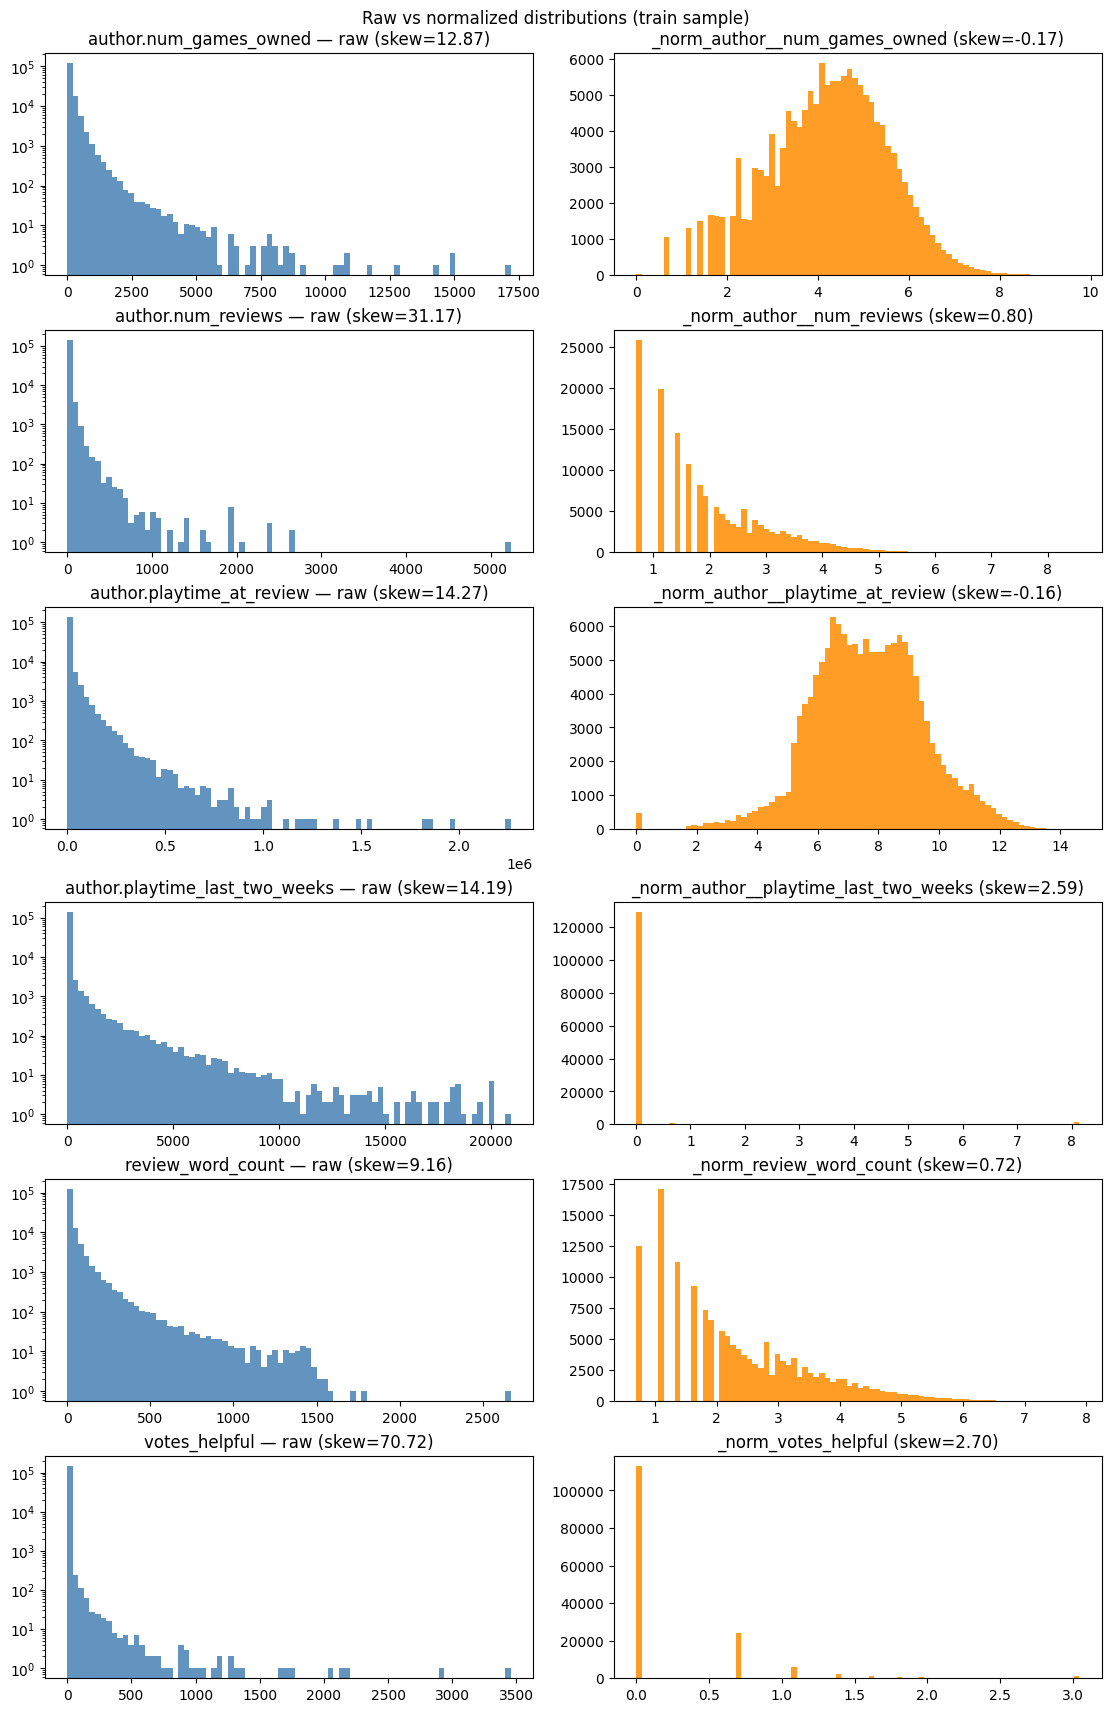

In [8]:
n_feat = len(fitted)
fig, axes = plt.subplots(n_feat, 2, figsize=(11, 2.8 * n_feat), constrained_layout=True)
if n_feat == 1:
    axes = axes.reshape(1, -1)

for i, src in enumerate(sorted(fitted.keys())):
    nc = make_norm_col_name(src)
    raw = pd.to_numeric(df_eda[src], errors="coerce").fillna(0.0)
    normed = pd.to_numeric(df_eda[nc], errors="coerce")
    ax0, ax1 = axes[i, 0], axes[i, 1]
    ax0.hist(raw.clip(lower=0), bins=80, color="steelblue", alpha=0.85)
    ax0.set_title(f"{src} — raw (skew={raw.skew():.2f})")
    ax0.set_yscale("log")
    ax1.hist(normed, bins=80, color="darkorange", alpha=0.85)
    ax1.set_title(f"{nc} (skew={normed.skew():.2f})")

plt.suptitle("Raw vs normalized distributions (train sample)", y=1.01, fontsize=12)
plt.show()


### 6b) By `recommended` and `is_helpful` (`_norm_*`)

Same spirit as [eda_006_normalization_003_postnorm](../eda/eda_006_normalization_003_postnorm.ipynb): check that normalized features still **separate** by `recommended` and by `is_helpful`.


/tmp/ipykernel_45043/1489130841.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_l.boxplot(parts, labels=["not_rec", "rec"], showfliers=False)
/tmp/ipykernel_45043/1489130841.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_r.boxplot(parts2, labels=["not_helpful", "helpful"], showfliers=False)
/tmp/ipykernel_45043/1489130841.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_l.boxplot(parts, labels=["not_rec", "rec"], showfliers=False)
/tmp/ipykernel_45043/1489130841.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support 

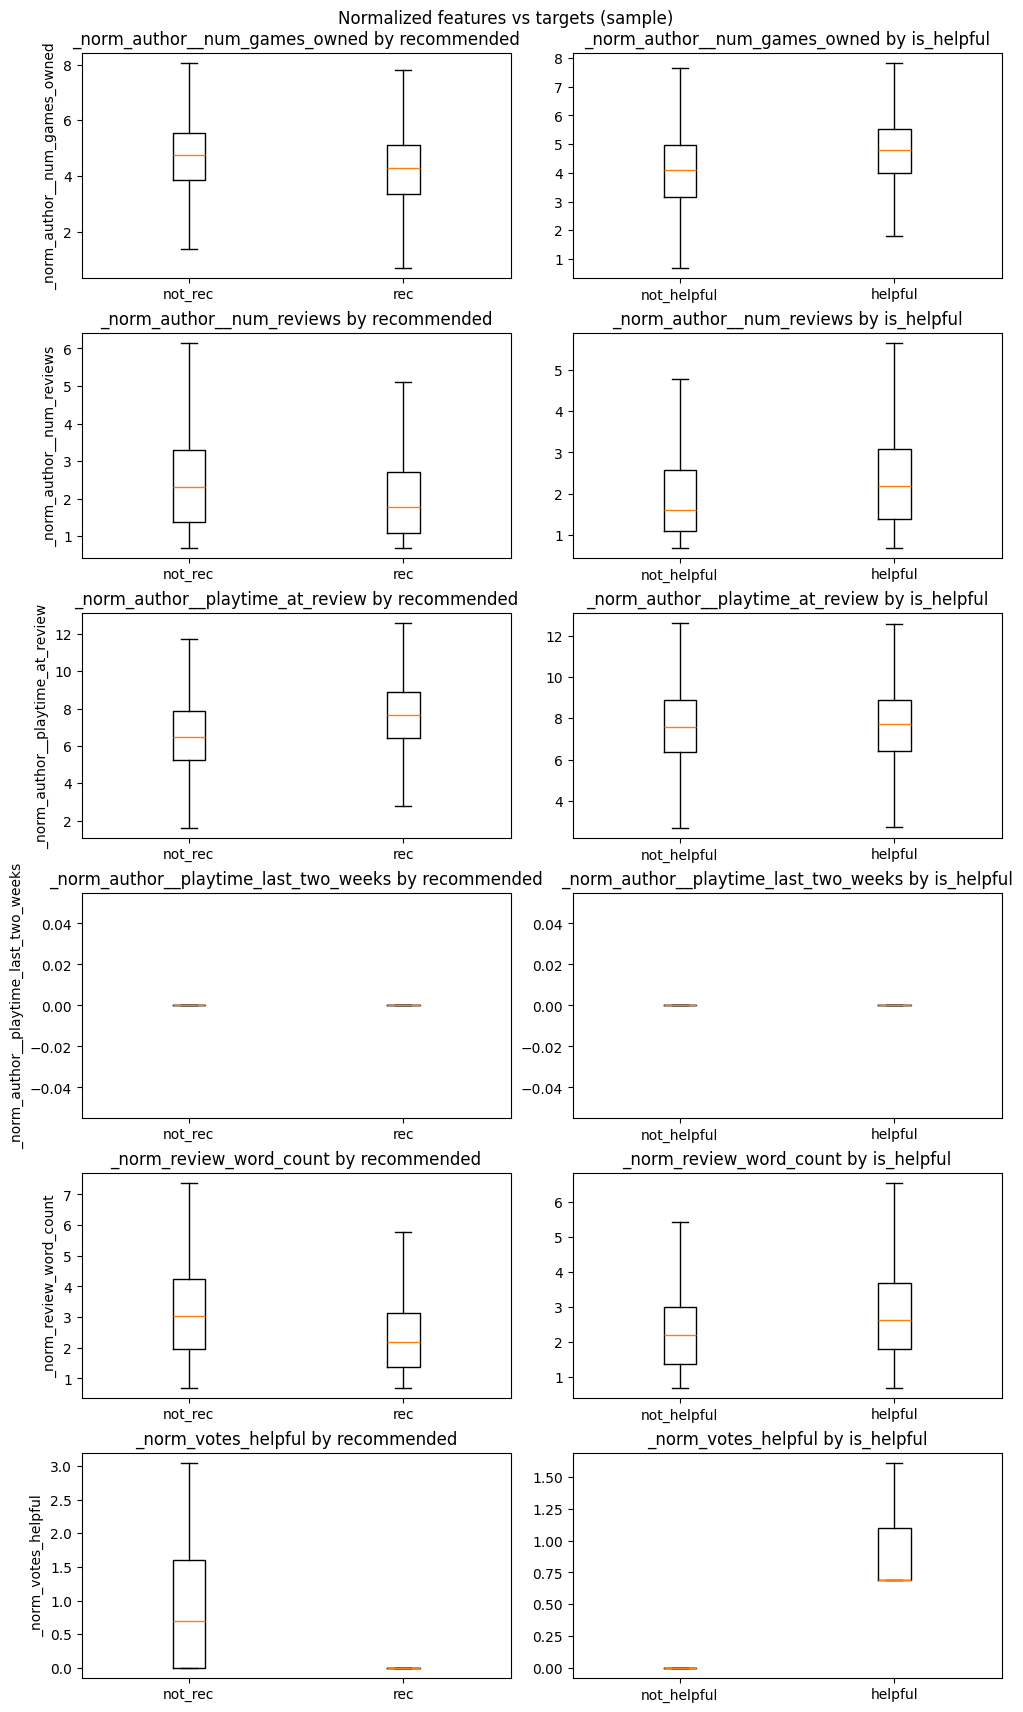

In [9]:
fig, axes = plt.subplots(len(norm_cols), 2, figsize=(10, 2.8 * len(norm_cols)), constrained_layout=True)
if len(norm_cols) == 1:
    axes = axes.reshape(1, -1)

for i, nc in enumerate(norm_cols):
    s = pd.to_numeric(df_eda[nc], errors="coerce").dropna()
    # Left: by recommended
    ax_l = axes[i, 0]
    parts = [
        pd.to_numeric(df_eda.loc[df_eda["recommended"] == 0, nc], errors="coerce").dropna(),
        pd.to_numeric(df_eda.loc[df_eda["recommended"] == 1, nc], errors="coerce").dropna(),
    ]
    ax_l.boxplot(parts, labels=["not_rec", "rec"], showfliers=False)
    ax_l.set_title(f"{nc} by recommended")
    ax_l.set_ylabel(nc)

    ax_r = axes[i, 1]
    parts2 = [
        pd.to_numeric(df_eda.loc[df_eda["is_helpful"] == 0, nc], errors="coerce").dropna(),
        pd.to_numeric(df_eda.loc[df_eda["is_helpful"] == 1, nc], errors="coerce").dropna(),
    ]
    ax_r.boxplot(parts2, labels=["not_helpful", "helpful"], showfliers=False)
    ax_r.set_title(f"{nc} by is_helpful")

plt.suptitle("Normalized features vs targets (sample)", y=1.01, fontsize=12)
plt.show()


### 6c) `_norm_*` vs `_norm_votes_helpful` (dense scatter, sample)

Quick association check in **transform space** (useful for regression on normalized helpfulness).


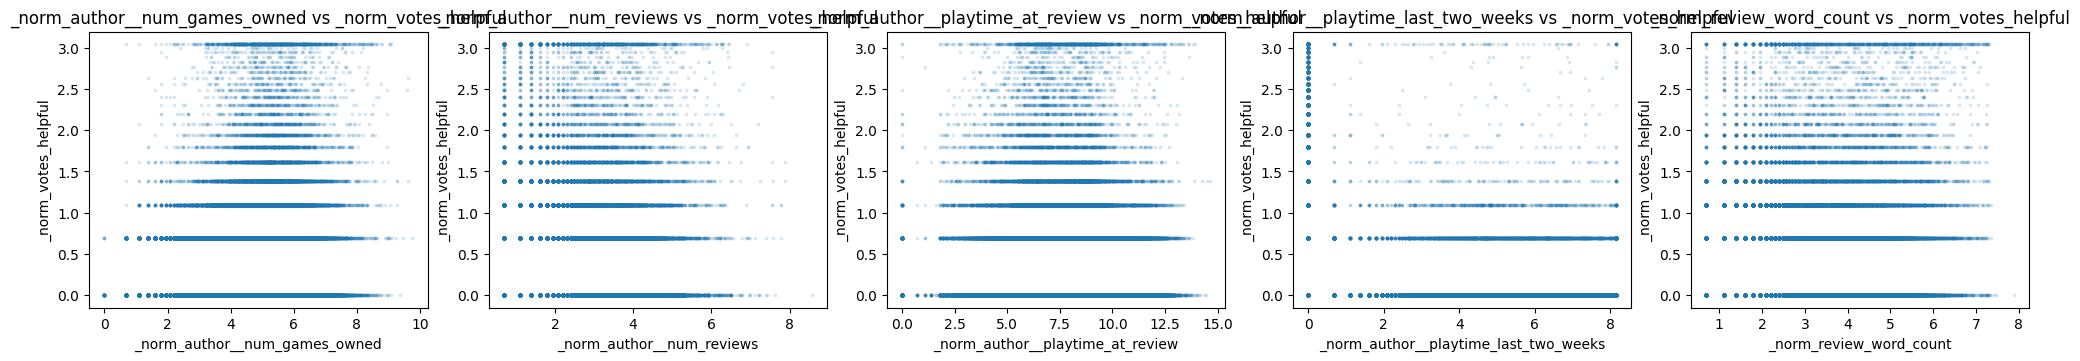

In [10]:
yt = "_norm_votes_helpful" if "_norm_votes_helpful" in df_eda.columns else None
if yt:
    cols_plot = [c for c in norm_cols if c != yt]
    if not cols_plot:
        print("Only votes_helpful normalized; nothing to scatter vs target.")
    else:
        n_plots = len(cols_plot)
        fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 3.5), constrained_layout=True)
        if n_plots == 1:
            axes = [axes]
        for ax, nc in zip(axes, cols_plot):
            ax.scatter(
                pd.to_numeric(df_eda[nc], errors="coerce"),
                pd.to_numeric(df_eda[yt], errors="coerce"),
                alpha=0.12,
                s=3,
                c="tab:blue",
            )
            ax.set_xlabel(nc)
            ax.set_ylabel(yt)
            ax.set_title(f"{nc} vs {yt}")
        plt.show()
else:
    print("No _norm_votes_helpful on frame; skip scatter grid.")


### 6d) Correlation heatmap — `_norm_*` only


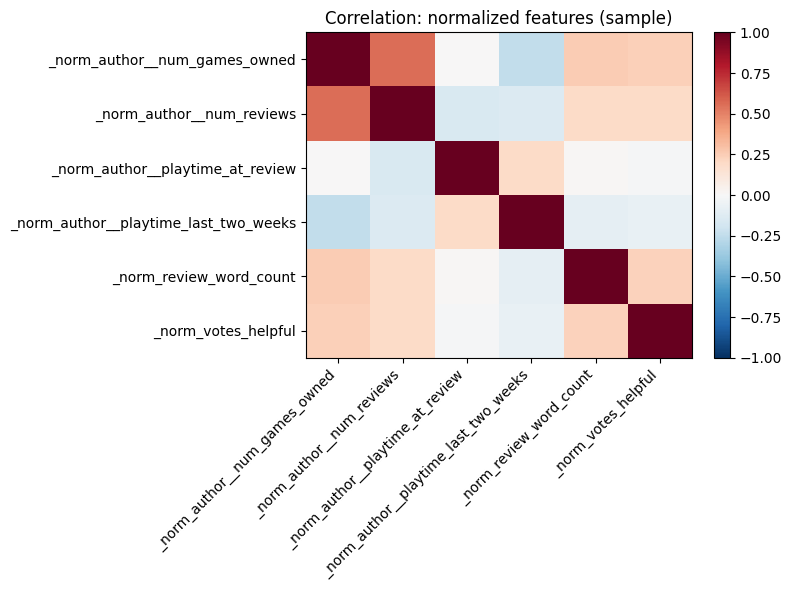

                                       _norm_author__num_games_owned  \
_norm_author__num_games_owned                                  1.000   
_norm_author__num_reviews                                      0.559   
_norm_author__playtime_at_review                               0.007   
_norm_author__playtime_last_two_weeks                         -0.245   
_norm_review_word_count                                        0.252   
_norm_votes_helpful                                            0.240   

                                       _norm_author__num_reviews  \
_norm_author__num_games_owned                              0.559   
_norm_author__num_reviews                                  1.000   
_norm_author__playtime_at_review                          -0.153   
_norm_author__playtime_last_two_weeks                     -0.136   
_norm_review_word_count                                    0.189   
_norm_votes_helpful                                        0.189   

                  

In [11]:
cmat = df_eda[norm_cols].apply(pd.to_numeric, errors="coerce").corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cmat.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(norm_cols)))
ax.set_yticks(range(len(norm_cols)))
ax.set_xticklabels(norm_cols, rotation=45, ha="right")
ax.set_yticklabels(norm_cols)
ax.set_title("Correlation: normalized features (sample)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
print(cmat.round(3))


### 6e) Tail / “outlier” counts on `_norm_*` (z-score in sample)

Not a hard gate — just flags columns with many extreme **normalized** values after the cap/log pipeline.


In [12]:
Z_THRESH = 4.0
rows = []
for nc in norm_cols:
    x = pd.to_numeric(df_eda[nc], errors="coerce").dropna()
    z = (x - x.mean()) / x.std(ddof=0)
    frac = (z.abs() > Z_THRESH).mean()
    rows.append((nc, float(frac), float(z.max()), float(z.min())))

out = pd.DataFrame(rows, columns=["_norm_col", "frac_abs_z_gt_4", "z_max", "z_min"]).sort_values(
    "frac_abs_z_gt_4", ascending=False
)
print(out.to_string(index=False))
print("If frac_abs_z_gt_4 is large for a column, inspect cap/log choice or heavy tails.")


                            _norm_col  frac_abs_z_gt_4    z_max     z_min
                  _norm_votes_helpful         0.013580 5.467535 -0.482930
     _norm_author__playtime_at_review         0.003147 3.766734 -4.114139
            _norm_author__num_reviews         0.000647 6.081975 -1.205187
              _norm_review_word_count         0.000060 4.472580 -1.405101
        _norm_author__num_games_owned         0.000027 4.177477 -3.181868
_norm_author__playtime_last_two_weeks         0.000000 3.968793 -0.373787
If frac_abs_z_gt_4 is large for a column, inspect cap/log choice or heavy tails.
